Import Libraries

In [384]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from itertools import chain, combinations

import joblib

Set Dataset Path

In [385]:
DATA_PATH = "../datasets/patuakhali_soil_element (Ec,PH,NPKS).xlsm - English Data (1).csv"

Load Dataset

In [386]:
df = pd.read_csv(DATA_PATH)
df.head()

,sl_no,district,land_class,soil_texture,ph,ec,om,n,pb,po,k,s,zn,b,ca,mg,cu,mn
0,4,Ramgati,Medium high land,Loam,8.0,1.63,0.95,0.06,18.19,NaN,0.07,20.30,0.09,0.35,7.06,1.83,0.70,1.08
1,5,Rangamati,Medium high land,Loam,6.5,1.25,1.31,0.08,0.00,2.64,0.07,12.01,0.14,0.32,4.22,2.65,1.34,1.57
2,27,Rangamati,Medium high land,Loam,6.8,5.59,1.34,0.08,4.78,NaN,0.07,94.54,0.16,0.32,6.58,2.28,0.89,1.12
3,29,Rangamati,Medium high land,Loam,5.4,1.67,1.94,0.11,NaN,4.13,0.09,16.80,0.16,0.35,2.50,2.10,1.72,2.01
4,44,Rangamati,Medium high land,Loam,6.3,0.99,1.35,0.08,NaN,2.19,0.08,20.32,0.15,0.39,4.00,2.61,1.29,2.45


In [387]:
df["om"] = pd.to_numeric(df["om"], errors='coerce')

In [388]:
filter = df["po"].notna() & df["pb"].notna()
df.loc[filter, ["po", "pb"]]

,po,pb
1,2.64,0.0


In [389]:
merged_p = "p"

if "po" in df.columns and "pb" in df.columns:
    df[merged_p] = df["po"].combine_first(df["pb"])
    df = df.drop(columns=["po", "pb"])

df.columns
    

Index(['sl_no', 'district', 'land_class', 'soil_texture', 'ph', 'ec', 'om',
       'n', 'k', 's', 'zn', 'b', 'ca', 'mg', 'cu', 'mn', 'p'],
      dtype='object')

In [390]:
TARGET = 'k'
df[TARGET].describe()

count    94.000000
mean      0.184362
std       0.085792
min       0.070000
25%       0.130000
50%       0.170000
75%       0.207500
max       0.520000
Name: k, dtype: float64

In [391]:
numeric_columns = [
    "ph",
    "ec",
    "om",
    "n",
    "p",
    "k",
    "s",
    "ca",
    "mg"
]

categorical_columns = [
    "district",
    "land_class",
    "soil_texture",
]

In [392]:
numeric_columns = [col for col in numeric_columns if col in df.columns and col not in [TARGET]]
categorical_columns = [col for col in categorical_columns if col in df.columns]

print(f"Numeric columns used: {len(numeric_columns)}")
print(numeric_columns)

print(f"\nCategorical columns used: {len(categorical_columns)}")
print(categorical_columns)

Numeric columns used: 8
['ph', 'ec', 'om', 'n', 'p', 's', 'ca', 'mg']

Categorical columns used: 3
['district', 'land_class', 'soil_texture']


In [393]:
for col in numeric_columns + [TARGET]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

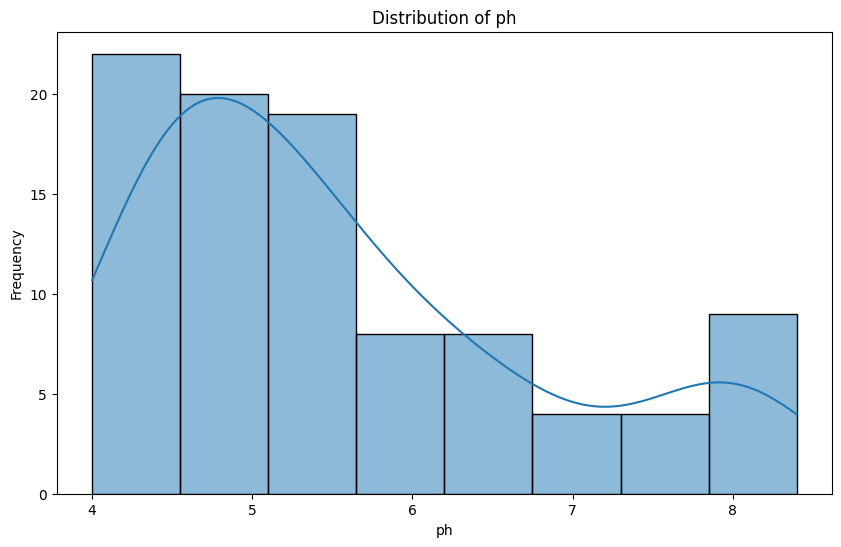

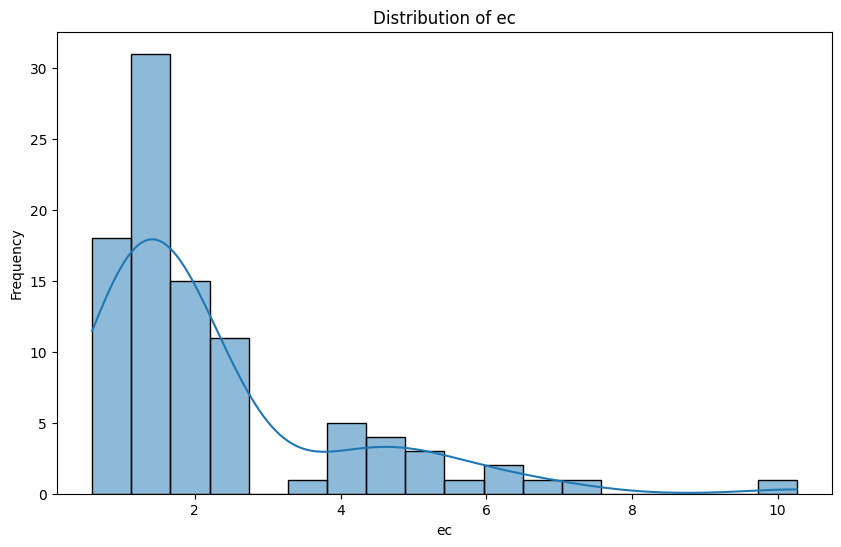

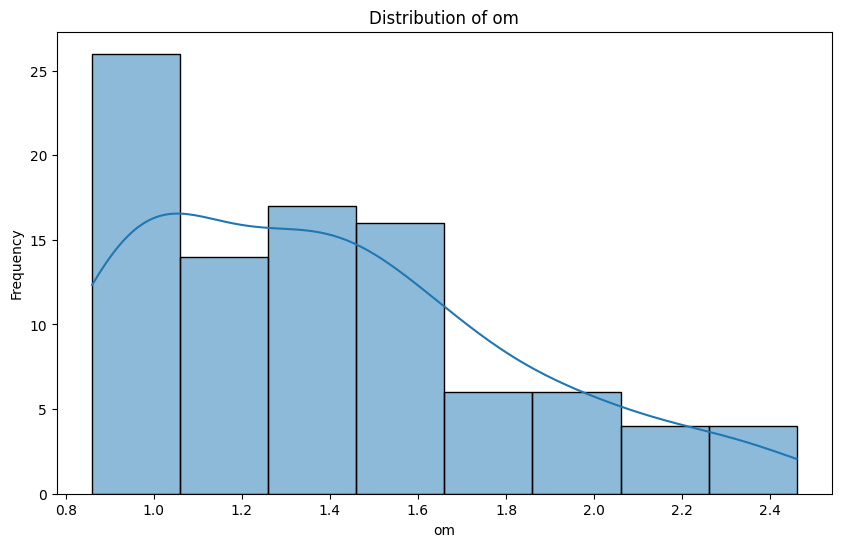

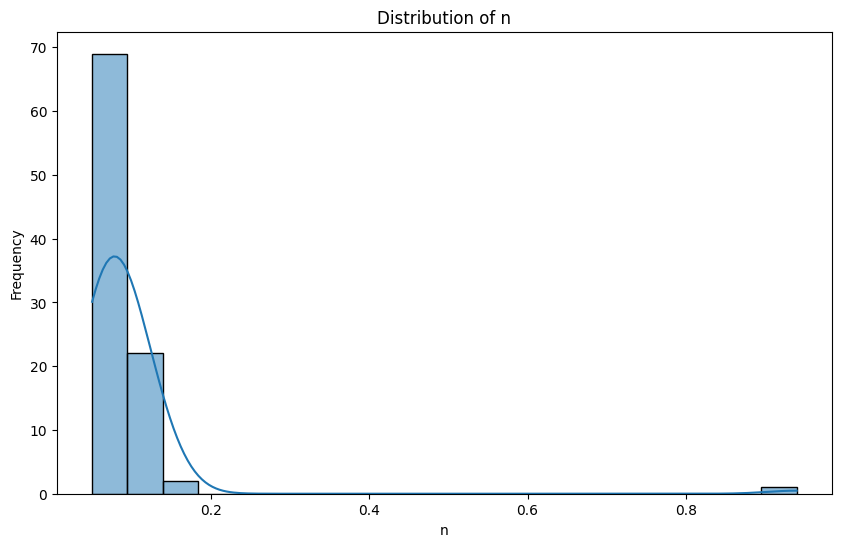

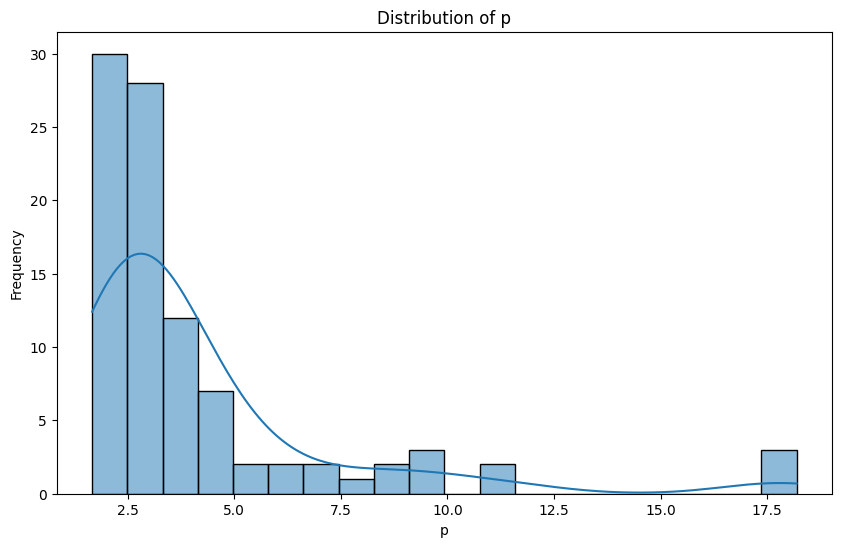

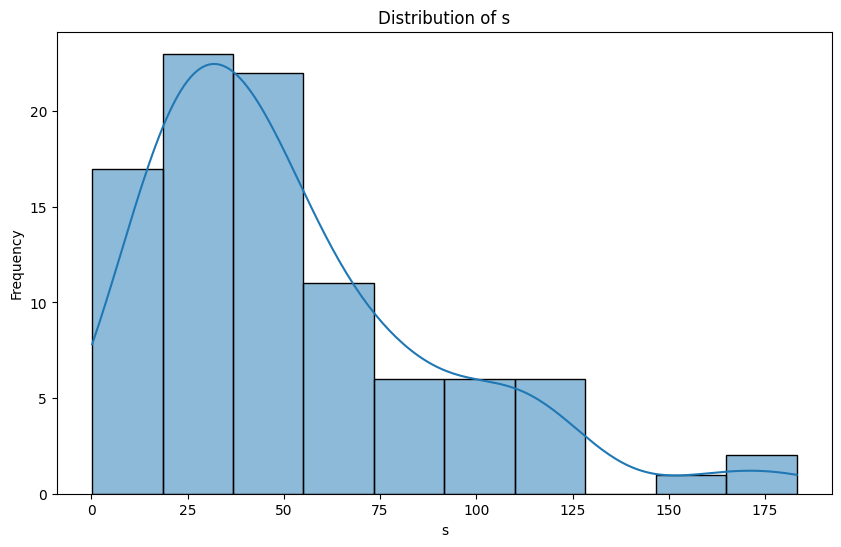

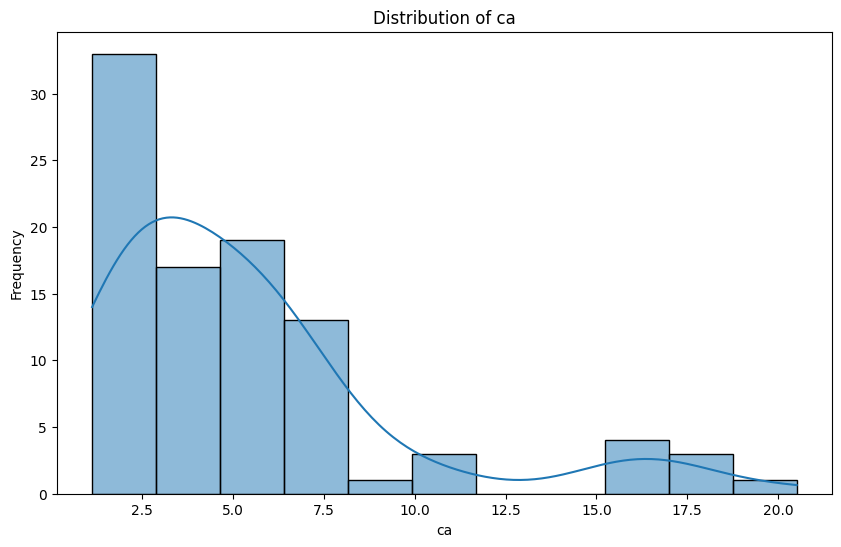

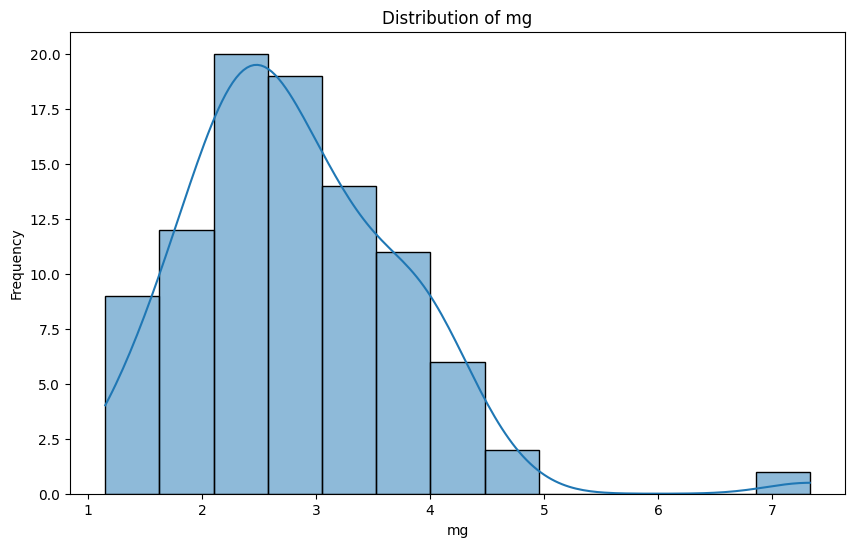

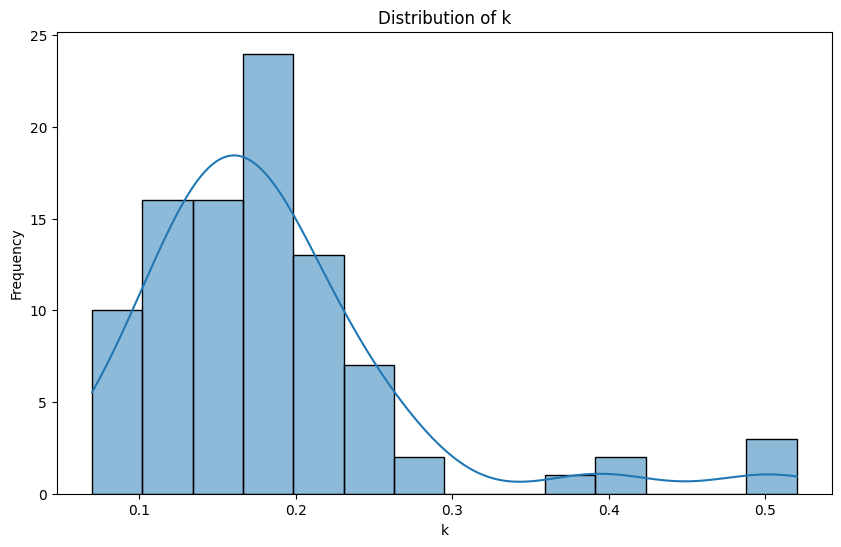

In [394]:
for col in numeric_columns + [TARGET]:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [395]:

df[TARGET].describe()

count    94.000000
mean      0.184362
std       0.085792
min       0.070000
25%       0.130000
50%       0.170000
75%       0.207500
max       0.520000
Name: k, dtype: float64

In [396]:
Q1 = df[TARGET].quantile(0.05)
Q3 = df[TARGET].quantile(0.95)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[TARGET] < lower_bound) | (df[TARGET] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Total outliers:", len(outliers))

print("Outliers with value > 5:", (df[TARGET] > 0.4).sum())

Lower bound: -0.3642499999999998
Upper bound: 0.8377499999999998
Total outliers: 0
Outliers with value > 5: 3


<Axes: >

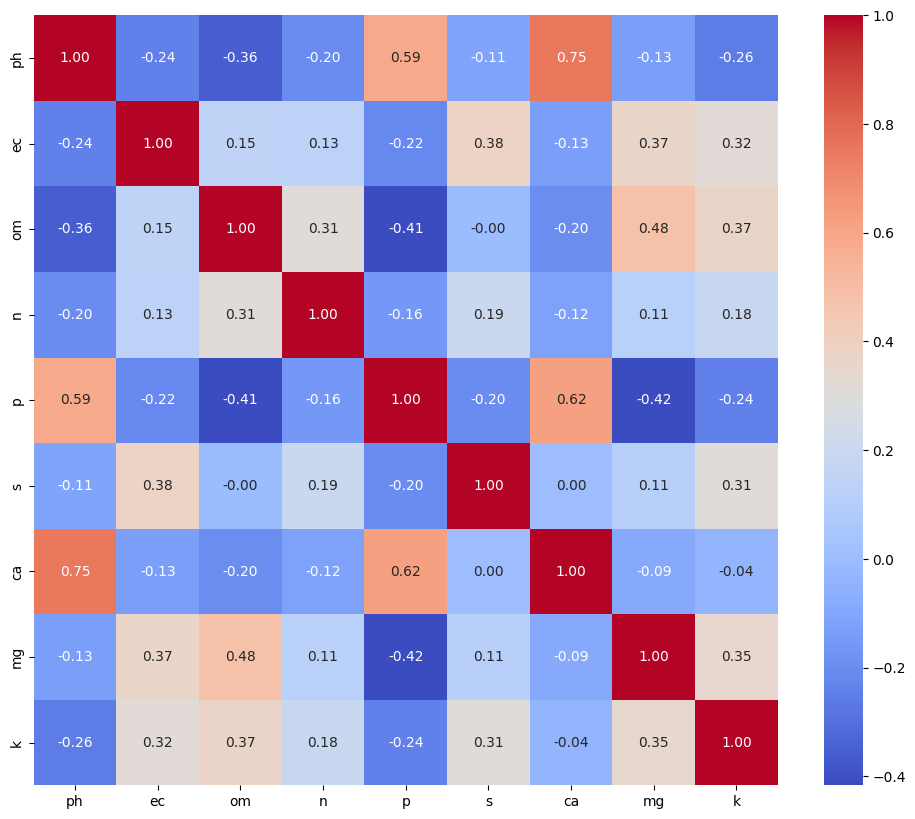

In [397]:
corr_cols = numeric_columns + [TARGET]
corr_df = df[corr_cols].copy()
plt.figure(figsize=(12,10))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [398]:
df[numeric_columns + [TARGET]].describe()

,ph,ec,om,n,p,s,ca,mg,k
count,94.000000,94.000000,93.000000,94.00000,94.000000,94.000000,94.000000,94.000000,94.000000
mean,5.543617,2.254362,1.392581,0.09067,4.165851,51.976277,5.354255,2.810532,0.184362
std,1.225321,1.752230,0.415880,0.09179,3.291729,37.614258,4.201484,0.945580,0.085792
min,4.000000,0.590000,0.860000,0.05000,1.670000,0.230000,1.120000,1.150000,0.070000
25%,4.600000,1.190000,1.020000,0.06000,2.412500,25.737500,2.415000,2.192500,0.130000
50%,5.250000,1.610000,1.350000,0.08000,2.930000,43.040000,4.275000,2.645000,0.170000
75%,6.200000,2.422500,1.630000,0.10000,4.152500,70.175000,6.535000,3.335000,0.207500
max,8.400000,10.260000,2.460000,0.94000,18.190000,183.200000,20.510000,7.330000,0.520000


In [399]:
df.loc[df["zn"] == 8.04, "zn"] = 0.84

In [400]:
df.loc[df["n"] == 0.94, "n"] = 0.094

In [401]:
df.describe()

,sl_no,ph,ec,om,n,k,s,zn,b,ca,mg,cu,mn,p
count,94.000000,94.000000,94.000000,93.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000
mean,46.808511,5.543617,2.254362,1.392581,0.081670,0.184362,51.976277,0.353404,0.385745,5.354255,2.810532,2.529149,7.772234,4.165851
std,26.884171,1.225321,1.752230,0.415880,0.024231,0.085792,37.614258,0.482365,0.140157,4.201484,0.945580,0.948367,9.429750,3.291729
min,1.000000,4.000000,0.590000,0.860000,0.050000,0.070000,0.230000,0.050000,0.100000,1.120000,1.150000,0.700000,0.640000,1.670000
25%,24.250000,4.600000,1.190000,1.020000,0.060000,0.130000,25.737500,0.100000,0.300000,2.415000,2.192500,1.805000,2.620000,2.412500
50%,46.500000,5.250000,1.610000,1.350000,0.080000,0.170000,43.040000,0.190000,0.365000,4.275000,2.645000,2.300000,5.080000,2.930000
75%,69.750000,6.200000,2.422500,1.630000,0.098500,0.207500,70.175000,0.365000,0.437500,6.535000,3.335000,3.465000,7.777500,4.152500
max,93.000000,8.400000,10.260000,2.460000,0.140000,0.520000,183.200000,2.880000,0.930000,20.510000,7.330000,4.600000,45.740000,18.190000


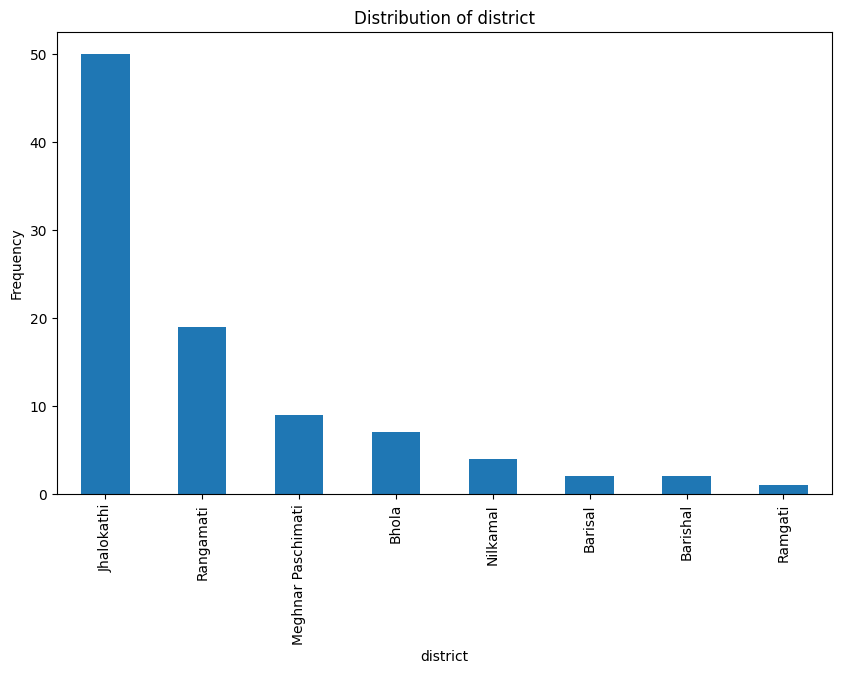

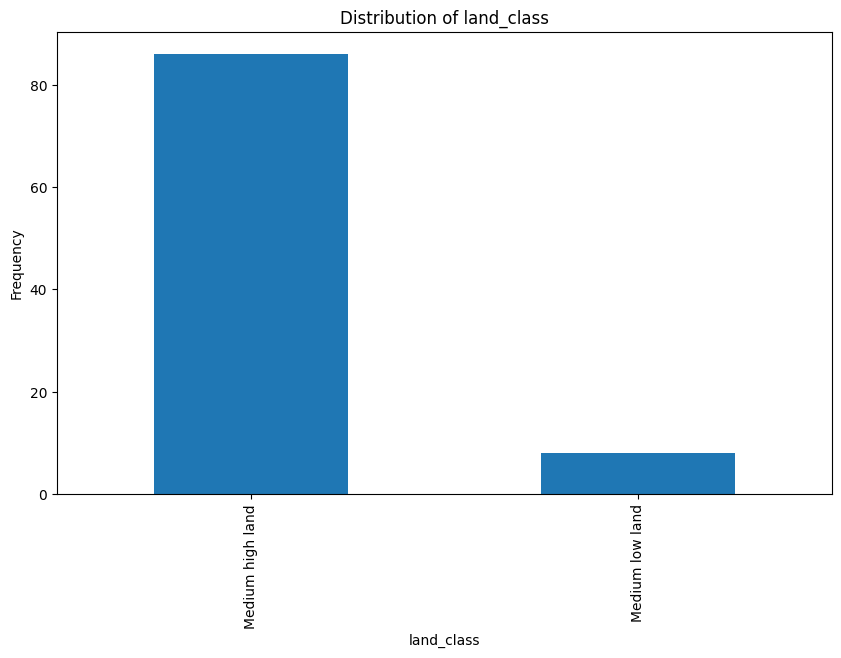

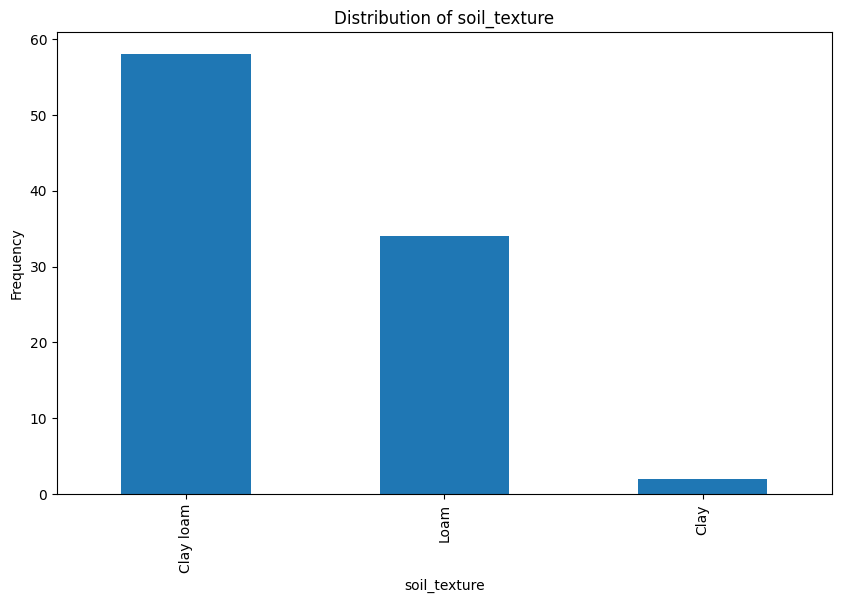

In [402]:
for cols in categorical_columns:
    plt.figure(figsize=(10,6))
    
    df[cols].value_counts().plot(kind='bar')
    
    plt.title(f"Distribution of {cols}")
    plt.xlabel(cols)
    plt.ylabel("Frequency")
    plt.show()

In [403]:
df["district"] = df["district"].replace({ "Barisal": "Barishal", "Rangamati": "Ramgati"})

In [404]:
df["district"].value_counts()

district
Jhalokathi            50
Ramgati               20
Meghnar Paschimati     9
Bhola                  7
Barishal               4
Nilkamal               4
Name: count, dtype: int64

Analyze the relationship between Nitrogen and categorical columns(District, Land Class, Soil Texture)

Category-wise N Distribution

In [405]:
for col in categorical_columns:
    print(f"\nRelationship between {col} and {TARGET}")
    print(df.groupby(col)[TARGET].agg(["mean", "median", "std"]))


Relationship between district and k
                        mean  median       std
district                                      
Barishal            0.195000   0.180  0.036968
Bhola               0.142857   0.130  0.046085
Jhalokathi          0.209000   0.190  0.100107
Meghnar Paschimati  0.138889   0.140  0.009280
Nilkamal            0.222500   0.225  0.056789
Ramgati             0.148000   0.145  0.061781

Relationship between land_class and k
                      mean  median       std
land_class                                  
Medium high land  0.188488   0.175  0.088564
Medium low land   0.140000   0.140  0.009258

Relationship between soil_texture and k
                  mean  median       std
soil_texture                            
Clay          0.215000   0.215  0.049497
Clay loam     0.205690   0.190  0.096229
Loam          0.146176   0.140  0.048117


Interpretation of ANOVA

ANOVA means Analysis of Variance.

It is a statistical test used to check whether the average value of a numerical column is significantly different across multiple categories/groups.

Example:

Does average Total Nitrogen (%) differ across Districts?

ANOVA tells:

p-value < 0.05  → group averages are significantly different
p-value >= 0.05 → no strong evidence of difference

In simple words: ANOVA checks whether categories have meaningfully different average values.

In [406]:
from scipy.stats import f_oneway

for col in categorical_columns:
    print(f"\nANOVA for {col} and {TARGET}")
    groups = [group[TARGET] for name, group in df.groupby(col)]
    f_stat, p_value = f_oneway(*groups)

    print("F-statistic:", f_stat)
    print("p-value:", p_value)


ANOVA for district and k
F-statistic: 2.7924850434099993
p-value: 0.021781522763906696

ANOVA for land_class and k
F-statistic: 2.3724672403171154
p-value: 0.1269243515751225

ANOVA for soil_texture and k
F-statistic: 5.83764243377005
p-value: 0.004117979230347968


Boxplot Observation

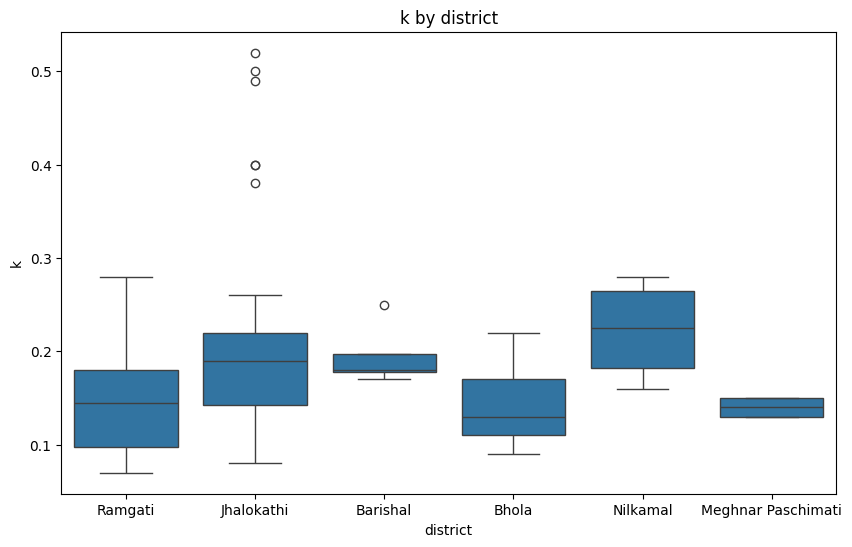

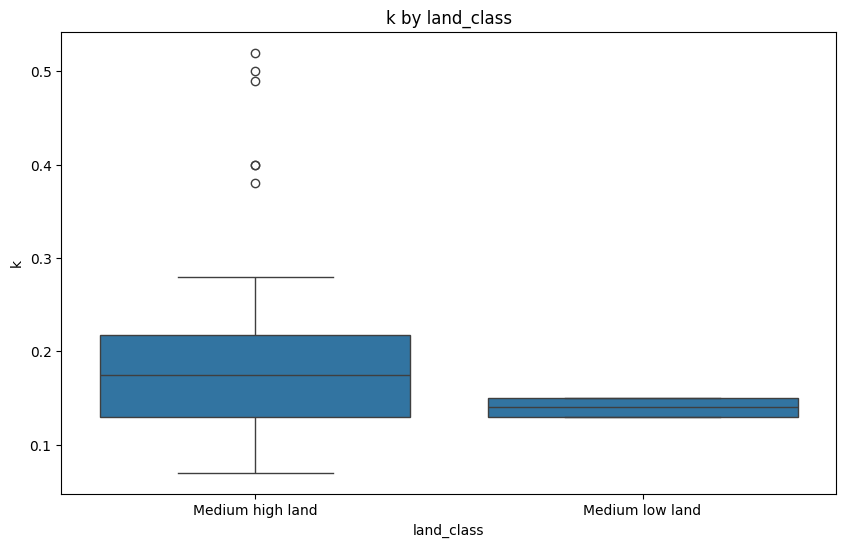

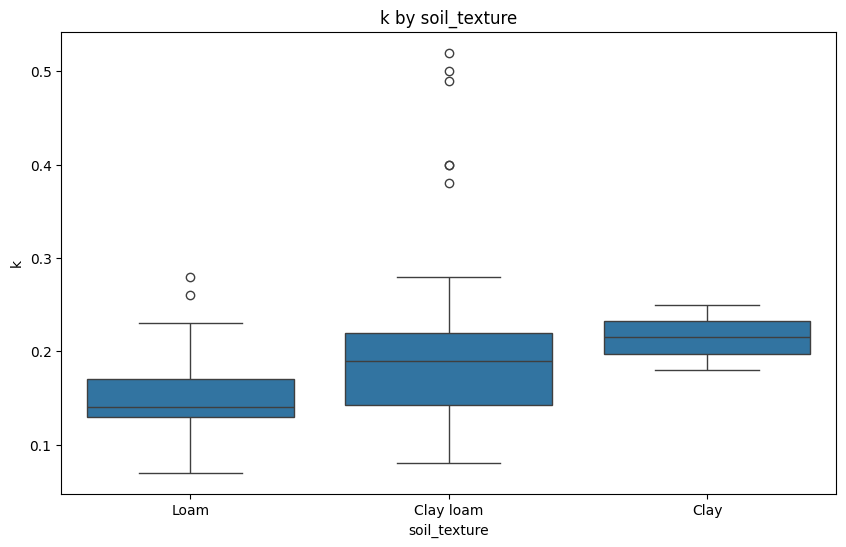

In [407]:
for col in categorical_columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=col, y=TARGET, data=df)
    plt.title(f"{TARGET} by {col}")
    plt.show()

In [408]:
from scipy.stats import pearsonr
for col in numeric_columns:
    corr, p_value = pearsonr(df[col], df[TARGET])
    
    print(f"\n{col}")
    print("Pearson correlation:", corr)
    print("p-value:", p_value)


ph
Pearson correlation: -0.2611254974277153
p-value: 0.011018855149075309

ec
Pearson correlation: 0.3161909650543281
p-value: 0.0019051721332935113

om
Pearson correlation: nan
p-value: nan

n
Pearson correlation: 0.3606033482353003
p-value: 0.0003565548734347713

p
Pearson correlation: -0.24007651721959147
p-value: 0.019770177548125104

s
Pearson correlation: 0.3105014170804798
p-value: 0.0023206045674511273

ca
Pearson correlation: -0.03750167245992569
p-value: 0.7197045867044981

mg
Pearson correlation: 0.34940473649576015
p-value: 0.0005569722819728463


corr near +1  = strong positive linear relation
corr near -1  = strong negative linear relation
corr near 0   = weak/no linear relation

In [409]:
feature_columns = numeric_columns + categorical_columns

X = df[feature_columns].copy()
y = df[TARGET].copy()

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (94, 11)
Target (y) shape: (94,)


In [410]:
print(X.columns)

Index(['ph', 'ec', 'om', 'n', 'p', 's', 'ca', 'mg', 'district', 'land_class',
       'soil_texture'],
      dtype='object')


Train Test Split

In [411]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Training target shape:", y_train.shape) 
print("Testing features shape:", X_test.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (75, 11)
Training target shape: (75,)
Testing features shape: (19, 11)
Testing target shape: (19,)


Create Preprocessing Pipeline

In [412]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [413]:
MLFLOW_TRACKING_URI = r"file:../mlruns"
EXPERIMENT_NAME = "k_prediction_3_combinations"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

2026/05/21 16:58:25 INFO mlflow.tracking.fluent: Experiment with name 'k_prediction_3_combinations' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:d:/project/n-prediction-mlflow/train/../mlruns/463022199809591458', creation_time=1779361105818, experiment_id='463022199809591458', last_update_time=1779361105818, lifecycle_stage='active', name='k_prediction_3_combinations', tags={}, trace_location=None, workspace='default'>

In [414]:
models_and_params = {
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {
            "regressor__n_estimators": [100],
            "regressor__max_depth": [10]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(),
        "params": {
            "regressor__n_estimators": [100],
            "regressor__max_depth": [3]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "regressor__kernel": ["rbf", "linear"],
        },
    },
}

In [415]:
best_r2_score = float('-inf')
best_pipeline = None
best_info = None

In [416]:
def feature_combination(total_features, static_features, combination_size):

    if combination_size is None:
        combination_size = len(total_features)
    if combination_size > len(total_features):
        raise ValueError("Combination size cannot be greater than the total number of features.")
    if static_features is not None:
        dynamic_features = [feature for feature in total_features if feature not in static_features]
    else:
        dynamic_features = total_features
    
    combination_size =  combination_size - len(static_features)
    
    comb = list(combinations(dynamic_features, combination_size))
    
    for i in range(len(comb)):
        comb[i] = list(comb[i]) + static_features
    
    return comb

In [417]:
results = []

for columns in feature_combination(total_features=numeric_columns+categorical_columns, static_features=[], combination_size=3):
    
    selected_categorical_columns = [cat_col for cat_col in categorical_columns if cat_col in columns]
    selected_numeric_columns = [num_col for num_col in numeric_columns if num_col in columns]

    selected_columns = selected_numeric_columns + selected_categorical_columns
    combo_name = "_".join([col.split()[0] for col in selected_columns])

    print(f"\n{'='*70}")
    print(f"Feature Combination: {selected_columns} ({len(selected_columns)} numeric features)")
    print(f"Combo Name: {combo_name}")
    print(f"{'='*70}")

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy='median')),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("onehot", OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
    transformers=[
            ("num", numeric_transformer, selected_numeric_columns),
            ("cat", categorical_transformer, selected_categorical_columns)
        ]
    )

    for model_name, config in models_and_params.items():
        model = config["model"]
        param_grid = list(ParameterGrid(config["params"]))
        
        print(f"→ Training {model_name} | Total hyperparameter runs: {len(param_grid)}")
        
        for run_number, params in enumerate(param_grid, start=1):
            with mlflow.start_run(run_name=f"{model_name}_{combo_name}_run_{run_number}"):
                pipeline = Pipeline(steps=[
                    ("preprocessor", preprocessor),
                    ("regressor", model)
                ])
                pipeline.set_params(**params)
                pipeline.fit(X_train, y_train)
                y_train_pred = pipeline.predict(X_train)
                y_test_pred = pipeline.predict(X_test)
                
                train_metrics = evaluate_model(y_train, y_train_pred)
                test_metrics = evaluate_model(y_test, y_test_pred)
                
                current_test_r2 = test_metrics["R2 Score"]
                if current_test_r2 > best_r2_score:
                    best_r2_score = current_test_r2
                    best_pipeline  =pipeline
                    best_info = {
                            "model_name": model_name,
                            "combo_name": combo_name,
                            "test_r2": current_test_r2,
                            "params": params,
                            "num_features": len(selected_numeric_columns),
                            "target": TARGET
                        }
                
                mlflow.log_param("model_name", model_name)
                mlflow.log_param("feature_combo", combo_name)
                mlflow.log_param("selected_numeric_features", selected_numeric_columns)
                mlflow.log_param("num_numeric_features", len(selected_numeric_columns))
                mlflow.log_param("total_features", len(selected_numeric_columns) + len(selected_categorical_columns))
                mlflow.log_param("target", TARGET)
                 
                for param_name, param_value in params.items():
                    clean_param_name = param_name.replace("regressor__", "")
                    mlflow.log_param(clean_param_name, param_value)
                
                mlflow.log_metric("train_MAE", train_metrics["MAE"])
                mlflow.log_metric("train_MSE", train_metrics["MSE"])
                mlflow.log_metric("train_RMSE", train_metrics["RMSE"])
                mlflow.log_metric("train_R2", train_metrics["R2 Score"])

                mlflow.log_metric("test_MAE", test_metrics["MAE"])
                mlflow.log_metric("test_MSE", test_metrics["MSE"])
                mlflow.log_metric("test_RMSE", test_metrics["RMSE"])
                mlflow.log_metric("test_R2", test_metrics["R2 Score"])
                
                mlflow.sklearn.log_model(pipeline, artifact_path="model")
                
                result_row = {
                    "model_name": model_name,
                    "combo_name": combo_name,
                    "num_features": len(selected_numeric_columns),
                    "features_used": selected_numeric_columns,
                    "params": params,
                    "train_metrics": train_metrics,
                    "test_metrics": test_metrics
                }
                
                results.append(result_row)
                
                print(
                    f"{model_name} run {run_number} | "
                    f"Test RMSE: {test_metrics['RMSE']:.4f} | "
                    f"Test R2: {test_metrics['R2 Score']:.4f}"
                )
                
                # save_path = "../models/p_prediction_model.pkl"
                # joblib.dump(best_pipeline, save_path)
            
print("\n" + "="*80)
print("TRAINING COMPLETED")
print(f"Best Model: {best_info['model_name']} | Combo: {best_info['combo_name']}")
print(f"Test R2: {best_info['test_r2']:.4f}")
print("="*80)


Feature Combination: ['ph', 'ec', 'om'] (3 numeric features)
Combo Name: ph_ec_om
→ Training RandomForest | Total hyperparameter runs: 1


2026/05/21 16:58:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 16:58:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest run 1 | Test RMSE: 0.0606 | Test R2: -1.4922
→ Training GradientBoosting | Total hyperparameter runs: 1


2026/05/21 16:58:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 16:58:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/21 16:58:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


GradientBoosting run 1 | Test RMSE: 0.0932 | Test R2: -4.8973
→ Training SVR | Total hyperparameter runs: 2


...

GradientBoosting run 1 | Test RMSE: 0.0457 | Test R2: -0.4189
→ Training SVR | Total hyperparameter runs: 2


2026/05/21 17:39:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 17:39:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVR run 1 | Test RMSE: 0.0486 | Test R2: -0.6018


2026/05/21 17:40:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/21 17:40:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


SVR run 2 | Test RMSE: 0.0481 | Test R2: -0.5740

TRAINING COMPLETED
Best Model: RandomForest | Combo: ph_n_ca
Test R2: 0.4161


In [418]:
# save_path = "../models/k_prediction_model.pkl"
# joblib.dump(best_pipeline, save_path)

In [419]:
best_info   

{'model_name': 'RandomForest',
 'combo_name': 'ph_n_ca',
 'test_r2': 0.4160924450316741,
 'params': {'regressor__max_depth': 10, 'regressor__n_estimators': 100},
 'num_features': 3,
 'target': 'k'}